
# GVH Diagonal Cubic 0.2.8 — Field Equations and Effective Source
## Équations de champ, source effective, conservation et conditions d'énergie

**Auteur : Charlemagne O Laurince**

---

## Objectif

Ce notebook prolonge la chaîne géométrique construite dans les versions 0.2.1 à 0.2.7.

La question centrale devient :

> Quelle source ou quelle équation de champ correspond à une métrique diagonale cubique GVH candidate ?

Dans la relativité générale :

\[
G_{\mu\nu}
+
\Lambda g_{\mu\nu}
=
\frac{8\pi G}{c^4}T_{\mu\nu}.
\]

Pour une métrique candidate donnée, on peut définir un tenseur effectif :

\[
T_{\mu\nu}^{\mathrm{eff}}
=
\frac{c^4}{8\pi G}
\left(
G_{\mu\nu}
+
\Lambda g_{\mu\nu}
\right).
\]

Cela ne démontre pas que cette source existe physiquement. Il s'agit d'abord d'une reconstruction géométrique.

---

## Séparation scientifique

Le notebook distingue :

1. **équation établie de référence** : équations d'Einstein ;
2. **reconstruction effective** : source nécessaire pour soutenir une métrique donnée ;
3. **hypothèse GVH** : éventuelle nouvelle équation de champ, qui reste à dériver.

Une métrique seule n'est pas une théorie complète.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

G_N = 6.67430e-11
c = 299_792_458.0

print("Environnement chargé.")


Environnement chargé.



# 1. Moteur tensoriel général

Nous réutilisons la chaîne :

\[
g_{\mu\nu}
\rightarrow
\Gamma^\rho_{\mu\nu}
\rightarrow
R^\rho{}_{\sigma\mu\nu}
\rightarrow
R_{\mu\nu}
\rightarrow
R
\rightarrow
G_{\mu\nu}.
\]


In [2]:

def christoffel_symbols(metric_cov, coordinates, simplify_each=True):
    metric_cov = sp.Matrix(metric_cov)
    n = len(coordinates)
    metric_inv = sp.simplify(metric_cov.inv())

    Gamma = [[[sp.Integer(0) for _ in range(n)]
              for _ in range(n)]
             for _ in range(n)]

    for rho in range(n):
        for mu in range(n):
            for nu in range(n):
                expr = sp.Integer(0)

                for sigma in range(n):
                    expr += metric_inv[rho, sigma] * (
                        sp.diff(metric_cov[sigma, nu], coordinates[mu])
                        + sp.diff(metric_cov[sigma, mu], coordinates[nu])
                        - sp.diff(metric_cov[mu, nu], coordinates[sigma])
                    )

                expr *= sp.Rational(1, 2)
                Gamma[rho][mu][nu] = (
                    sp.simplify(expr) if simplify_each else expr
                )

    return Gamma


def riemann_tensor(Gamma, coordinates, simplify_each=True):
    n = len(coordinates)

    Riemann = [[[[sp.Integer(0) for _ in range(n)]
                 for _ in range(n)]
                for _ in range(n)]
               for _ in range(n)]

    for rho in range(n):
        for sigma in range(n):
            for mu in range(n):
                for nu in range(n):
                    expr = (
                        sp.diff(Gamma[rho][nu][sigma], coordinates[mu])
                        - sp.diff(Gamma[rho][mu][sigma], coordinates[nu])
                    )

                    for lam in range(n):
                        expr += (
                            Gamma[rho][mu][lam] * Gamma[lam][nu][sigma]
                            - Gamma[rho][nu][lam] * Gamma[lam][mu][sigma]
                        )

                    Riemann[rho][sigma][mu][nu] = (
                        sp.simplify(expr) if simplify_each else expr
                    )

    return Riemann


def ricci_tensor(Riemann, simplify_each=True):
    n = len(Riemann)
    Ricci = sp.MutableDenseMatrix.zeros(n, n)

    for mu in range(n):
        for nu in range(n):
            expr = sp.Integer(0)

            for rho in range(n):
                expr += Riemann[rho][mu][rho][nu]

            Ricci[mu, nu] = (
                sp.simplify(expr) if simplify_each else expr
            )

    return sp.Matrix(Ricci)


def ricci_scalar(metric_cov, Ricci):
    metric_inv = sp.simplify(sp.Matrix(metric_cov).inv())
    n = metric_inv.shape[0]

    expr = sp.Integer(0)

    for mu in range(n):
        for nu in range(n):
            expr += metric_inv[mu, nu] * Ricci[mu, nu]

    return sp.simplify(expr)


def einstein_tensor(metric_cov, Ricci, scalar_R):
    metric_cov = sp.Matrix(metric_cov)
    n = metric_cov.shape[0]
    Einstein = sp.MutableDenseMatrix.zeros(n, n)

    for mu in range(n):
        for nu in range(n):
            Einstein[mu, nu] = sp.simplify(
                Ricci[mu, nu]
                - sp.Rational(1, 2) * metric_cov[mu, nu] * scalar_R
            )

    return sp.Matrix(Einstein)



# 2. Source effective

Nous définissons :

\[
\kappa
=
\frac{8\pi G}{c^4},
\]

et

\[
T_{\mu\nu}^{\mathrm{eff}}
=
\frac{1}{\kappa}
\left(
G_{\mu\nu}
+
\Lambda g_{\mu\nu}
\right).
\]

En unités géométriques \(G=c=1\) :

\[
\kappa=8\pi.
\]


In [3]:

def effective_stress_energy(
    metric_cov,
    Einstein,
    Lambda=sp.Integer(0),
    geometric_units=True
):
    metric_cov = sp.Matrix(metric_cov)
    Einstein = sp.Matrix(Einstein)

    if geometric_units:
        kappa = 8*sp.pi
    else:
        kappa = 8*sp.pi*sp.Symbol("G_N", positive=True) / sp.Symbol(
            "c", positive=True
        )**4

    return sp.simplify(
        (Einstein + Lambda*metric_cov) / kappa
    )



# 3. Test de référence — Minkowski sans constante cosmologique

Pour Minkowski et \(\Lambda=0\) :

\[
G_{\mu\nu}=0,
\qquad
T_{\mu\nu}^{\mathrm{eff}}=0.
\]


In [4]:

t, x, y, z = sp.symbols("t x y z", real=True)
coords_mink = (t, x, y, z)

g_mink = sp.diag(-1, 1, 1, 1)

Gamma_mink = christoffel_symbols(g_mink, coords_mink)
Riemann_mink = riemann_tensor(Gamma_mink, coords_mink)
Ricci_mink = ricci_tensor(Riemann_mink)
R_mink = ricci_scalar(g_mink, Ricci_mink)
G_mink = einstein_tensor(g_mink, Ricci_mink, R_mink)
T_mink = effective_stress_energy(g_mink, G_mink)

print("G_mink =")
display(G_mink)

print("T_eff_mink =")
display(T_mink)


G_mink =


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

T_eff_mink =


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 4. Constante cosmologique comme source effective

Avec Minkowski mais \(\Lambda\neq0\) :

\[
T_{\mu\nu}^{(\Lambda)}
=
\frac{\Lambda}{8\pi}g_{\mu\nu}
\]

en unités géométriques.

Cette source possède une densité d'énergie constante et une pression négative.


In [5]:

Lambda = sp.symbols("Lambda", real=True)

T_lambda = effective_stress_energy(
    g_mink,
    G_mink,
    Lambda=Lambda,
    geometric_units=True
)

print("T_eff pour Minkowski + Lambda :")
display(T_lambda)


T_eff pour Minkowski + Lambda :


⎡-Λ                ⎤
⎢───   0    0    0 ⎥
⎢8⋅π               ⎥
⎢                  ⎥
⎢      Λ           ⎥
⎢ 0   ───   0    0 ⎥
⎢     8⋅π          ⎥
⎢                  ⎥
⎢           Λ      ⎥
⎢ 0    0   ───   0 ⎥
⎢          8⋅π     ⎥
⎢                  ⎥
⎢                Λ ⎥
⎢ 0    0    0   ───⎥
⎣               8⋅π⎦


# 5. Test de référence — Schwarzschild extérieur

Pour la métrique de Schwarzschild dans le vide :

\[
G_{\mu\nu}=0.
\]

Donc, si \(\Lambda=0\) :

\[
T_{\mu\nu}^{\mathrm{eff}}=0.
\]


In [6]:

ts, rs, ths, phs, M = sp.symbols(
    "t_s r_s theta_s phi_s M",
    positive=True,
    real=True
)

coords_schw = (ts, rs, ths, phs)
f = 1 - 2*M/rs

g_schw = sp.diag(
    -f,
    1/f,
    rs**2,
    rs**2*sp.sin(ths)**2
)

Gamma_schw = christoffel_symbols(g_schw, coords_schw)
Riemann_schw = riemann_tensor(Gamma_schw, coords_schw)
Ricci_schw = ricci_tensor(Riemann_schw)
R_schw = ricci_scalar(g_schw, Ricci_schw)
G_schw = einstein_tensor(g_schw, Ricci_schw, R_schw)
T_schw = effective_stress_energy(g_schw, G_schw)

print("Ricci Schwarzschild :")
display(Ricci_schw)

print("Scalaire de Ricci :", R_schw)

print("T_eff Schwarzschild :")
display(T_schw)


Ricci Schwarzschild :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

Scalaire de Ricci : 0
T_eff Schwarzschild :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 6. Métrique statique sphérique générale

Pour analyser une source effective, nous utilisons la forme :

\[
ds^2
=
-e^{2\Phi(r)}dt^2
+
e^{2\Lambda_r(r)}dr^2
+
r^2d\Omega^2.
\]

Cette notation distingue la fonction métrique radiale \(\Lambda_r(r)\) de la constante cosmologique \(\Lambda\).


In [7]:

tg, rg, theta_g, phi_g = sp.symbols(
    "t_g r_g theta_g phi_g",
    real=True,
    positive=True
)

coords_general = (tg, rg, theta_g, phi_g)

Phi = sp.Function("Phi")(rg)
Lam_r = sp.Function("Lam_r")(rg)

g_general = sp.diag(
    -sp.exp(2*Phi),
    sp.exp(2*Lam_r),
    rg**2,
    rg**2*sp.sin(theta_g)**2
)

print("Métrique générale :")
display(g_general)


Métrique générale :


⎡  2⋅Φ(r_g)                                    ⎤
⎢-ℯ               0         0          0       ⎥
⎢                                              ⎥
⎢             2⋅Lamᵣ(r_g)                      ⎥
⎢    0       ℯ              0          0       ⎥
⎢                                              ⎥
⎢                             2                ⎥
⎢    0            0        r_g         0       ⎥
⎢                                              ⎥
⎢                                   2    2     ⎥
⎣    0            0         0    r_g ⋅sin (θ_g)⎦


## Calcul du tenseur d'Einstein général

Cette cellule peut prendre du temps dans Colab mobile. Elle est néanmoins plus légère que le calcul complet d'une métrique cartésienne isotrope arbitraire.


In [8]:

Gamma_general = christoffel_symbols(
    g_general,
    coords_general,
    simplify_each=True
)

Riemann_general = riemann_tensor(
    Gamma_general,
    coords_general,
    simplify_each=True
)

Ricci_general = ricci_tensor(Riemann_general)
R_general = ricci_scalar(g_general, Ricci_general)
G_general = einstein_tensor(
    g_general,
    Ricci_general,
    R_general
)

print("Composantes diagonales de G_mu_nu :")

for i in range(4):
    print(f"G[{i},{i}] =")
    display(sp.factor(G_general[i, i]))


Composantes diagonales de G_mu_nu :
G[0,0] =


⎛       d                 2⋅Lamᵣ(r_g)    ⎞  -2⋅Lamᵣ(r_g)  2⋅Φ(r_g)
⎜2⋅r_g⋅────(Lamᵣ(r_g)) + ℯ            - 1⎟⋅ℯ            ⋅ℯ        
⎝      dr_g                              ⎠                        
──────────────────────────────────────────────────────────────────
                                  2                               
                               r_g                                

G[1,1] =


       d              2⋅Lamᵣ(r_g)    
2⋅r_g⋅────(Φ(r_g)) - ℯ            + 1
      dr_g                           
─────────────────────────────────────
                   2                 
                r_g                  

G[2,2] =


     ⎛                                                     2         2         ↪
     ⎜     d               d                 ⎛ d          ⎞         d          ↪
-r_g⋅⎜r_g⋅────(Lamᵣ(r_g))⋅────(Φ(r_g)) - r_g⋅⎜────(Φ(r_g))⎟  - r_g⋅─────(Φ(r_g ↪
     ⎜    dr_g            dr_g               ⎝dr_g        ⎠            2       ↪
     ⎝                                                             dr_g        ↪

↪                                    ⎞              
↪       d                 d          ⎟  -2⋅Lamᵣ(r_g)
↪ )) + ────(Lamᵣ(r_g)) - ────(Φ(r_g))⎟⋅ℯ            
↪      dr_g              dr_g        ⎟              
↪                                    ⎠              

G[3,3] =


     ⎛                                                     2         2         ↪
     ⎜     d               d                 ⎛ d          ⎞         d          ↪
-r_g⋅⎜r_g⋅────(Lamᵣ(r_g))⋅────(Φ(r_g)) - r_g⋅⎜────(Φ(r_g))⎟  - r_g⋅─────(Φ(r_g ↪
     ⎜    dr_g            dr_g               ⎝dr_g        ⎠            2       ↪
     ⎝                                                             dr_g        ↪

↪                                    ⎞                        
↪       d                 d          ⎟  -2⋅Lamᵣ(r_g)    2     
↪ )) + ────(Lamᵣ(r_g)) - ────(Φ(r_g))⎟⋅ℯ            ⋅sin (θ_g)
↪      dr_g              dr_g        ⎟                        
↪                                    ⎠                        


# 7. Densité et pressions effectives

Dans une base orthonormée adaptée à un observateur statique, une source sphérique anisotrope peut s'écrire :

\[
T_{\hat\mu\hat\nu}
=
\operatorname{diag}
(\rho,p_r,p_t,p_t).
\]

À partir des composantes coordonnées :

\[
\rho
=
\frac{T_{tt}}{-g_{tt}},
\]

\[
p_r
=
\frac{T_{rr}}{g_{rr}},
\]

\[
p_t
=
\frac{T_{\theta\theta}}{g_{\theta\theta}}.
\]


In [9]:

T_general = effective_stress_energy(
    g_general,
    G_general,
    Lambda=0,
    geometric_units=True
)

rho_eff = sp.simplify(T_general[0,0] / (-g_general[0,0]))
p_r_eff = sp.simplify(T_general[1,1] / g_general[1,1])
p_t_eff = sp.simplify(T_general[2,2] / g_general[2,2])

print("rho_eff =")
display(sp.factor(rho_eff))

print("p_r_eff =")
display(sp.factor(p_r_eff))

print("p_t_eff =")
display(sp.factor(p_t_eff))


rho_eff =


⎛       d                 2⋅Lamᵣ(r_g)    ⎞  -2⋅Lamᵣ(r_g)
⎜2⋅r_g⋅────(Lamᵣ(r_g)) + ℯ            - 1⎟⋅ℯ            
⎝      dr_g                              ⎠              
────────────────────────────────────────────────────────
                               2                        
                        8⋅π⋅r_g                         

p_r_eff =


⎛       d              2⋅Lamᵣ(r_g)    ⎞  -2⋅Lamᵣ(r_g)
⎜2⋅r_g⋅────(Φ(r_g)) - ℯ            + 1⎟⋅ℯ            
⎝      dr_g                           ⎠              
─────────────────────────────────────────────────────
                             2                       
                      8⋅π⋅r_g                        

p_t_eff =


 ⎛                                                     2         2             ↪
 ⎜     d               d                 ⎛ d          ⎞         d              ↪
-⎜r_g⋅────(Lamᵣ(r_g))⋅────(Φ(r_g)) - r_g⋅⎜────(Φ(r_g))⎟  - r_g⋅─────(Φ(r_g)) + ↪
 ⎜    dr_g            dr_g               ⎝dr_g        ⎠            2           ↪
 ⎝                                                             dr_g            ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                           8⋅π⋅r_g             ↪

↪                                ⎞               
↪   d                 d          ⎟  -2⋅Lamᵣ(r_g) 
↪  ────(Lamᵣ(r_g)) - ────(Φ(r_g))⎟⋅ℯ             
↪  dr_g              dr_g        ⎟               
↪                                ⎠               
↪ ───────────────────────────────────────────────
↪                                                


# 8. Conditions d'énergie

Pour une source anisotrope :

## Condition d'énergie nulle — NEC

\[
\rho+p_r\ge0,
\qquad
\rho+p_t\ge0.
\]

## Condition d'énergie faible — WEC

\[
\rho\ge0,
\qquad
\rho+p_r\ge0,
\qquad
\rho+p_t\ge0.
\]

## Condition d'énergie dominante — DEC

\[
\rho\ge |p_r|,
\qquad
\rho\ge |p_t|.
\]

## Condition d'énergie forte — SEC

\[
\rho+p_r+2p_t\ge0,
\]

avec les NEC.


In [10]:

energy_conditions_symbolic = {
    "NEC_radial": sp.simplify(rho_eff + p_r_eff),
    "NEC_tangential": sp.simplify(rho_eff + p_t_eff),
    "WEC_density": sp.simplify(rho_eff),
    "SEC_trace": sp.simplify(rho_eff + p_r_eff + 2*p_t_eff),
    "anisotropy": sp.simplify(p_t_eff - p_r_eff)
}

for name, expr in energy_conditions_symbolic.items():
    print(name, "=")
    display(sp.factor(expr))


NEC_radial =


⎛ d                 d          ⎞  -2⋅Lamᵣ(r_g)
⎜────(Lamᵣ(r_g)) + ────(Φ(r_g))⎟⋅ℯ            
⎝dr_g              dr_g        ⎠              
──────────────────────────────────────────────
                   4⋅π⋅r_g                    

NEC_tangential =


 ⎛                                                       2          2          ↪
 ⎜   2  d               d                2 ⎛ d          ⎞       2  d           ↪
-⎜r_g ⋅────(Lamᵣ(r_g))⋅────(Φ(r_g)) - r_g ⋅⎜────(Φ(r_g))⎟  - r_g ⋅─────(Φ(r_g) ↪
 ⎜     dr_g            dr_g                ⎝dr_g        ⎠             2        ↪
 ⎝                                                                dr_g         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                         8⋅π⋅r ↪

↪                                                              ⎞               ↪
↪          d                     d              2⋅Lamᵣ(r_g)    ⎟  -2⋅Lamᵣ(r_g) ↪
↪ ) - r_g⋅────(Lamᵣ(r_g)) - r_g⋅────(Φ(r_g)) - ℯ            + 1⎟⋅ℯ             ↪
↪         dr_g                  dr_g                           ⎟               ↪
↪                          

WEC_density =


⎛       d                 2⋅Lamᵣ(r_g)    ⎞  -2⋅Lamᵣ(r_g)
⎜2⋅r_g⋅────(Lamᵣ(r_g)) + ℯ            - 1⎟⋅ℯ            
⎝      dr_g                              ⎠              
────────────────────────────────────────────────────────
                               2                        
                        8⋅π⋅r_g                         

SEC_trace =


 ⎛                                                     2         2             ↪
 ⎜     d               d                 ⎛ d          ⎞         d              ↪
-⎜r_g⋅────(Lamᵣ(r_g))⋅────(Φ(r_g)) - r_g⋅⎜────(Φ(r_g))⎟  - r_g⋅─────(Φ(r_g)) - ↪
 ⎜    dr_g            dr_g               ⎝dr_g        ⎠            2           ↪
 ⎝                                                             dr_g            ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                   4⋅π⋅r_g                     ↪

↪                ⎞               
↪     d          ⎟  -2⋅Lamᵣ(r_g) 
↪  2⋅────(Φ(r_g))⎟⋅ℯ             
↪    dr_g        ⎟               
↪                ⎠               
↪ ───────────────────────────────
↪                                

anisotropy =


 ⎛                                                       2          2          ↪
 ⎜   2  d               d                2 ⎛ d          ⎞       2  d           ↪
-⎜r_g ⋅────(Lamᵣ(r_g))⋅────(Φ(r_g)) - r_g ⋅⎜────(Φ(r_g))⎟  - r_g ⋅─────(Φ(r_g) ↪
 ⎜     dr_g            dr_g                ⎝dr_g        ⎠             2        ↪
 ⎝                                                                dr_g         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                         8⋅π⋅r ↪

↪                                                              ⎞               ↪
↪          d                     d              2⋅Lamᵣ(r_g)    ⎟  -2⋅Lamᵣ(r_g) ↪
↪ ) + r_g⋅────(Lamᵣ(r_g)) + r_g⋅────(Φ(r_g)) - ℯ            + 1⎟⋅ℯ             ↪
↪         dr_g                  dr_g                           ⎟               ↪
↪                          


# 9. Représentation par fonction de masse

Une métrique sphérique peut être écrite :

\[
e^{-2\Lambda_r(r)}
=
1-\frac{2m(r)}{r}.
\]

Dans la relativité générale :

\[
m'(r)=4\pi r^2\rho(r).
\]

Cette relation permet d'interpréter géométriquement la densité effective.


In [11]:

mfun = sp.Function("m")(rg)

replacement_Lam = sp.log(
    1 / sp.sqrt(1 - 2*mfun/rg)
)

rho_mass_form = sp.simplify(
    rho_eff.subs(Lam_r, replacement_Lam).doit()
)

print("rho_eff en fonction de m(r) :")
display(sp.factor(rho_mass_form))

expected_rho_mass = sp.diff(mfun, rg)/(4*sp.pi*rg**2)

print("Différence avec m'(r)/(4 pi r²) :")
display(sp.simplify(rho_mass_form - expected_rho_mass))


rho_eff en fonction de m(r) :


 d          
────(m(r_g))
dr_g        
────────────
         2  
  4⋅π⋅r_g   

Différence avec m'(r)/(4 pi r²) :


0


# 10. Conservation covariante

L'identité de Bianchi impose :

\[
\nabla_\mu G^{\mu\nu}=0.
\]

Par conséquent, pour les équations d'Einstein :

\[
\nabla_\mu T^{\mu\nu}=0.
\]

Pour une source sphérique anisotrope, l'équation hydrostatique généralisée est de type :

\[
p_r'
=
-(\rho+p_r)\Phi'
+
\frac{2}{r}(p_t-p_r).
\]

Nous vérifions symboliquement cette structure.


In [12]:

anisotropic_conservation = sp.simplify(
    sp.diff(p_r_eff, rg)
    + (rho_eff + p_r_eff)*sp.diff(Phi, rg)
    - 2*(p_t_eff-p_r_eff)/rg
)

print("Résidu de conservation anisotrope :")
display(sp.simplify(anisotropic_conservation))


Résidu de conservation anisotrope :


0


# 11. Candidat GVH en coordonnées isotropes

Nous reprenons la famille :

\[
A_{\mathrm{GVH}}(\chi)
=
1-2\chi+a_2\chi^2+a_3\chi^3,
\]

\[
B_{\mathrm{GVH}}(\chi)
=
1+2\gamma\chi+b_2\chi^2+b_3\chi^3.
\]

Pour reconstruire une source effective, nous convertissons le rayon isotrope \(\rho\) en rayon aréal :

\[
R(\rho)=\rho\sqrt{B(\rho)}.
\]

Puis :

\[
e^{2\Phi(R)}=A(\rho(R)).
\]

La composante radiale aréale satisfait :

\[
e^{2\Lambda_r(R)}
=
B(\rho)
\left(
\frac{d\rho}{dR}
\right)^2.
\]


In [13]:

CANDIDATE = {
    "a2": 2.0,
    "a3": -1.5,
    "gamma": 1.0,
    "b2": 1.5,
    "b3": 0.5
}

def metric_gvh_iso(rho, params=CANDIDATE):
    chi = 1.0/rho

    A = (
        1
        - 2*chi
        + params["a2"]*chi**2
        + params["a3"]*chi**3
    )

    B = (
        1
        + 2*params["gamma"]*chi
        + params["b2"]*chi**2
        + params["b3"]*chi**3
    )

    return A, B


def metric_schwarzschild_iso(rho):
    chi = 1.0/rho
    q = chi/2

    A = ((1-q)/(1+q))**2
    B = (1+q)**4

    return A, B



# 12. Reconstruction numérique de la source effective

Nous utilisons les relations connues pour une métrique aréale :

\[
ds^2=-A_R(R)dt^2+C_R(R)dR^2+R^2d\Omega^2.
\]

En posant :

\[
\Phi=\frac12\ln A_R,
\qquad
\Lambda_r=\frac12\ln C_R,
\]

on calcule numériquement :

\[
\rho_{\mathrm{eff}},
\quad
p_r^{\mathrm{eff}},
\quad
p_t^{\mathrm{eff}}.
\]

Les quantités sont exprimées en unités géométriques.


In [14]:

def derivative(func, x, rel_step=1e-5):
    h = max(abs(x)*rel_step, 1e-7)

    if x-h <= 0:
        return (func(x+h)-func(x))/h

    return (func(x+h)-func(x-h))/(2*h)


def second_derivative(func, x, rel_step=3e-4):
    h = max(abs(x)*rel_step, 1e-6)

    if x-h <= 0:
        return (func(x+2*h)-2*func(x+h)+func(x))/h**2

    return (func(x+h)-2*func(x)+func(x-h))/h**2


def areal_metric_from_isotropic(rho, model="gvh"):
    if model == "gvh":
        A, B = metric_gvh_iso(rho)
        metric_func = metric_gvh_iso
    elif model == "schwarzschild":
        A, B = metric_schwarzschild_iso(rho)
        metric_func = metric_schwarzschild_iso
    else:
        raise ValueError("model inconnu.")

    R = rho*np.sqrt(B)

    dR_drho = derivative(
        lambda rr: rr*np.sqrt(metric_func(rr)[1]),
        rho
    )

    C = B/(dR_drho**2)

    return R, A, C


def effective_fluid_numeric(rho, model="gvh"):
    R, A, C = areal_metric_from_isotropic(rho, model)

    def A_of_rho(rr):
        return areal_metric_from_isotropic(rr, model)[1]

    def C_of_rho(rr):
        return areal_metric_from_isotropic(rr, model)[2]

    def R_of_rho(rr):
        return areal_metric_from_isotropic(rr, model)[0]

    dR_drho = derivative(R_of_rho, rho)

    Phi_rho = 0.5*derivative(lambda rr: np.log(A_of_rho(rr)), rho)
    Lam_rho = 0.5*derivative(lambda rr: np.log(C_of_rho(rr)), rho)

    Phi_R = Phi_rho/dR_drho
    Lam_R = Lam_rho/dR_drho

    Phi_RR = derivative(
        lambda rr: (
            0.5*derivative(lambda uu: np.log(A_of_rho(uu)), rr)
            / derivative(R_of_rho, rr)
        ),
        rho
    ) / dR_drho

    exp_minus_2Lam = 1.0/C

    rho_eff_num = (
        exp_minus_2Lam*(2*R*Lam_R - 1) + 1
    ) / (8*np.pi*R**2)

    p_r_num = (
        exp_minus_2Lam*(2*R*Phi_R + 1) - 1
    ) / (8*np.pi*R**2)

    p_t_num = (
        exp_minus_2Lam * (
            Phi_RR
            + Phi_R**2
            - Phi_R*Lam_R
            + (Phi_R-Lam_R)/R
        )
    ) / (8*np.pi)

    return {
        "rho_iso": rho,
        "R_areal": R,
        "A": A,
        "C": C,
        "rho_eff": rho_eff_num,
        "p_r": p_r_num,
        "p_t": p_t_num
    }



# 13. Contrôle numérique sur Schwarzschild

Pour Schwarzschild extérieur, la reconstruction doit donner approximativement :

\[
\rho_{\mathrm{eff}}=0,
\qquad
p_r=0,
\qquad
p_t=0.
\]

Les résidus numériques servent de référence pour le niveau de bruit de dérivation.


In [15]:

rho_grid = np.logspace(np.log10(0.7), 2.0, 300)

schw_rows = []

for rho in rho_grid:
    try:
        row = effective_fluid_numeric(rho, "schwarzschild")
        schw_rows.append(row)
    except Exception:
        pass

schw_eff_df = pd.DataFrame(schw_rows)

schw_noise = {
    "max_abs_rho": schw_eff_df["rho_eff"].abs().max(),
    "max_abs_p_r": schw_eff_df["p_r"].abs().max(),
    "max_abs_p_t": schw_eff_df["p_t"].abs().max()
}

pd.DataFrame([schw_noise])


,max_abs_rho,max_abs_p_r,max_abs_p_t
0,2.781010e-08,3.703719e-12,2.141899e-08



# 14. Source effective du candidat GVH

Nous appliquons exactement la même reconstruction au candidat.

Toute source non nulle représente la matière ou la modification gravitationnelle effective requise par cette métrique dans le cadre des équations d'Einstein.


In [16]:

gvh_rows = []

for rho in rho_grid:
    try:
        row = effective_fluid_numeric(rho, "gvh")

        row["NEC_r"] = row["rho_eff"] + row["p_r"]
        row["NEC_t"] = row["rho_eff"] + row["p_t"]
        row["SEC"] = (
            row["rho_eff"]
            + row["p_r"]
            + 2*row["p_t"]
        )
        row["anisotropy"] = row["p_t"] - row["p_r"]

        gvh_rows.append(row)
    except Exception:
        pass

gvh_eff_df = pd.DataFrame(gvh_rows)
gvh_eff_df.head()


/tmp/ipykernel_4820/2258018637.py:55: RuntimeWarning: invalid value encountered in log
  Phi_rho = 0.5*derivative(lambda rr: np.log(A_of_rho(rr)), rho)
/tmp/ipykernel_4820/2258018637.py:63: RuntimeWarning: invalid value encountered in log
  0.5*derivative(lambda uu: np.log(A_of_rho(uu)), rr)


,rho_iso,R_areal,A,C,rho_eff,p_r,p_t,NEC_r,NEC_t,SEC,anisotropy
0,0.700000,2.025904,-2.148688,24.284778,0.001268,NaN,NaN,NaN,NaN,NaN,NaN
1,0.711713,2.032853,-2.022525,22.719666,0.001226,NaN,NaN,NaN,NaN,NaN,NaN
2,0.723623,2.040059,-1.903100,21.300092,0.001184,NaN,NaN,NaN,NaN,NaN,NaN
3,0.735731,2.047525,-1.790042,20.008815,0.001142,NaN,NaN,NaN,NaN,NaN,NaN
4,0.748042,2.055253,-1.683000,18.831056,0.001102,NaN,NaN,NaN,NaN,NaN,NaN


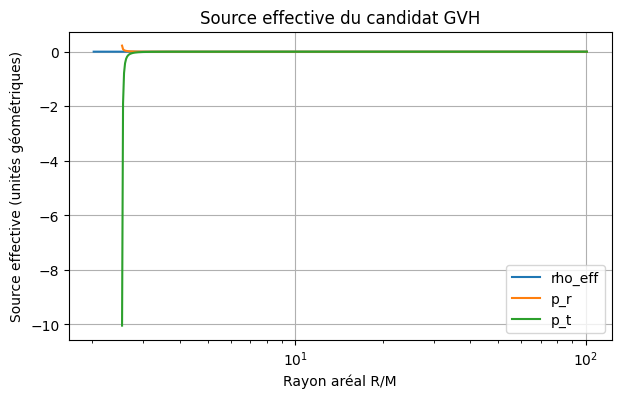

In [17]:

plt.figure(figsize=(7,4))
plt.plot(
    gvh_eff_df["R_areal"],
    gvh_eff_df["rho_eff"],
    label="rho_eff"
)
plt.plot(
    gvh_eff_df["R_areal"],
    gvh_eff_df["p_r"],
    label="p_r"
)
plt.plot(
    gvh_eff_df["R_areal"],
    gvh_eff_df["p_t"],
    label="p_t"
)

plt.xscale("log")
plt.xlabel("Rayon aréal R/M")
plt.ylabel("Source effective (unités géométriques)")
plt.title("Source effective du candidat GVH")
plt.grid(True)
plt.legend()
plt.show()


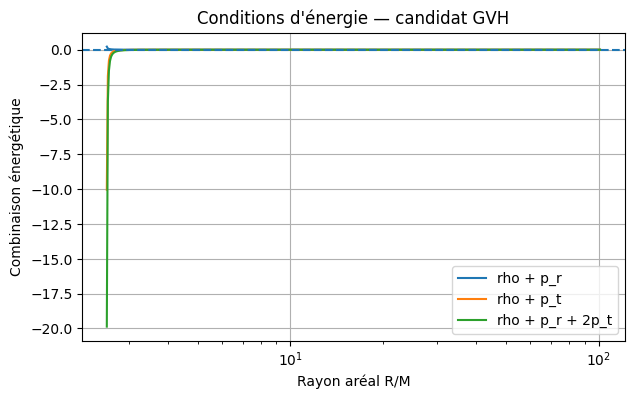

In [18]:

plt.figure(figsize=(7,4))
plt.plot(
    gvh_eff_df["R_areal"],
    gvh_eff_df["NEC_r"],
    label="rho + p_r"
)
plt.plot(
    gvh_eff_df["R_areal"],
    gvh_eff_df["NEC_t"],
    label="rho + p_t"
)
plt.plot(
    gvh_eff_df["R_areal"],
    gvh_eff_df["SEC"],
    label="rho + p_r + 2p_t"
)

plt.axhline(0.0, linestyle="--")
plt.xscale("log")
plt.xlabel("Rayon aréal R/M")
plt.ylabel("Combinaison énergétique")
plt.title("Conditions d'énergie — candidat GVH")
plt.grid(True)
plt.legend()
plt.show()



# 15. Classification des conditions d'énergie

Nous classons chaque point radial selon :

- WEC ;
- NEC ;
- DEC ;
- SEC.

Le test est numérique et dépend de la précision des dérivées.


In [19]:

def classify_energy_conditions(row, tolerance=1e-8):
    rho = row["rho_eff"]
    pr = row["p_r"]
    pt = row["p_t"]

    nec = (
        rho + pr >= -tolerance
        and rho + pt >= -tolerance
    )

    wec = (
        rho >= -tolerance
        and nec
    )

    dec = (
        rho >= -tolerance
        and rho >= abs(pr)-tolerance
        and rho >= abs(pt)-tolerance
    )

    sec = (
        nec
        and rho + pr + 2*pt >= -tolerance
    )

    return pd.Series({
        "NEC_pass": nec,
        "WEC_pass": wec,
        "DEC_pass": dec,
        "SEC_pass": sec
    })


energy_classification = gvh_eff_df.apply(
    classify_energy_conditions,
    axis=1
)

gvh_eff_df = pd.concat(
    [gvh_eff_df, energy_classification],
    axis=1
)

energy_summary = pd.DataFrame([{
    "N_points": len(gvh_eff_df),
    "NEC_fraction": gvh_eff_df["NEC_pass"].mean(),
    "WEC_fraction": gvh_eff_df["WEC_pass"].mean(),
    "DEC_fraction": gvh_eff_df["DEC_pass"].mean(),
    "SEC_fraction": gvh_eff_df["SEC_pass"].mean()
}])

energy_summary


,N_points,NEC_fraction,WEC_fraction,DEC_fraction,SEC_fraction
0,300,0.35,0.35,0.35,0.333333



# 16. Limite de vide

Une métrique extérieure destinée à remplacer Schwarzschild doit préciser si elle satisfait :

\[
T_{\mu\nu}^{\mathrm{eff}}
\rightarrow0
\]

lorsque :

\[
r\rightarrow\infty.
\]

Nous étudions les pentes asymptotiques numériques de :

\[
|\rho_{\mathrm{eff}}|,
\quad
|p_r|,
\quad
|p_t|.
\]


In [20]:

tail = gvh_eff_df[
    gvh_eff_df["R_areal"]
    > gvh_eff_df["R_areal"].quantile(0.7)
].copy()

def log_slope(x, y):
    mask = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (np.abs(y) > 0)
    )

    if mask.sum() < 3:
        return np.nan

    coeff = np.polyfit(
        np.log(x[mask]),
        np.log(np.abs(y[mask])),
        1
    )

    return coeff[0]


asymptotic_df = pd.DataFrame([{
    "rho_slope": log_slope(
        tail["R_areal"].to_numpy(),
        tail["rho_eff"].to_numpy()
    ),
    "p_r_slope": log_slope(
        tail["R_areal"].to_numpy(),
        tail["p_r"].to_numpy()
    ),
    "p_t_slope": log_slope(
        tail["R_areal"].to_numpy(),
        tail["p_t"].to_numpy()
    )
}])

asymptotic_df


,rho_slope,p_r_slope,p_t_slope
0,-2.102927,-6.101781,-5.207418



# 17. Équations de champ candidates

Plusieurs possibilités conceptuelles doivent être distinguées.

## Option A — Relativité générale avec source effective

\[
G_{\mu\nu}
=
8\pi T_{\mu\nu}^{\mathrm{eff}}.
\]

Dans ce cas, la métrique GVH nécessite une matière ou un champ effectif.

## Option B — Gravitation modifiée

\[
G_{\mu\nu}
+
H_{\mu\nu}^{\mathrm{GVH}}
=
8\pi T_{\mu\nu}.
\]

Le terme \(H_{\mu\nu}^{\mathrm{GVH}}\) doit être dérivé et satisfaire une conservation cohérente.

## Option C — Équation entièrement nouvelle

\[
\mathcal E_{\mu\nu}^{\mathrm{GVH}}
=
\kappa_{\mathrm{GVH}}T_{\mu\nu}.
\]

Cette possibilité exige une action, des symétries, une limite relativiste et des prédictions falsifiables.



# 18. Contraintes minimales sur un terme GVH

Un terme géométrique supplémentaire devrait idéalement satisfaire :

\[
\nabla_\mu H^{\mu\nu}_{\mathrm{GVH}}=0,
\]

ou être accompagné d'un échange explicite avec d'autres champs.

Il devrait aussi :

1. être covariant ;
2. avoir des dimensions cohérentes ;
3. retrouver Einstein dans une limite contrôlée ;
4. ne pas introduire arbitrairement un repère privilégié ;
5. préserver la causalité ;
6. être stable aux petites perturbations ;
7. produire une observable falsifiable.



# 19. Tableau de validation

Les tests de cette version portent sur :

- vide de Minkowski ;
- vide de Schwarzschild ;
- reconstruction de la densité via la fonction de masse ;
- conservation anisotrope ;
- bruit numérique sur Schwarzschild ;
- décroissance asymptotique du candidat.


In [21]:

mink_zero = all(
    sp.simplify(T_mink[i,j]) == 0
    for i in range(4)
    for j in range(4)
)

schw_zero = all(
    sp.simplify(T_schw[i,j]) == 0
    for i in range(4)
    for j in range(4)
)

mass_relation_ok = (
    sp.simplify(rho_mass_form-expected_rho_mass) == 0
)

conservation_ok = (
    sp.simplify(anisotropic_conservation) == 0
)

noise_level = max(schw_noise.values())

validation_rows = [
    {
        "test": "Minkowski source nulle",
        "value": 0.0 if mink_zero else 1.0,
        "threshold": 0.0,
        "status": "PASS" if mink_zero else "FAIL"
    },
    {
        "test": "Schwarzschild source nulle",
        "value": 0.0 if schw_zero else 1.0,
        "threshold": 0.0,
        "status": "PASS" if schw_zero else "FAIL"
    },
    {
        "test": "Relation m'(r)=4 pi r² rho",
        "value": 0.0 if mass_relation_ok else 1.0,
        "threshold": 0.0,
        "status": "PASS" if mass_relation_ok else "CHECK"
    },
    {
        "test": "Conservation anisotrope",
        "value": 0.0 if conservation_ok else 1.0,
        "threshold": 0.0,
        "status": "PASS" if conservation_ok else "CHECK"
    },
    {
        "test": "Bruit reconstruction Schwarzschild",
        "value": float(noise_level),
        "threshold": 1e-4,
        "status": "PASS" if noise_level < 1e-4 else "CHECK"
    }
]

validation_df = pd.DataFrame(validation_rows)
validation_df


,test,value,threshold,status
0,Minkowski source nulle,0.000000e+00,0.0000,PASS
1,Schwarzschild source nulle,0.000000e+00,0.0000,PASS
2,Relation m'(r)=4 pi r² rho,0.000000e+00,0.0000,PASS
3,Conservation anisotrope,0.000000e+00,0.0000,PASS
4,Bruit reconstruction Schwarzschild,2.781010e-08,0.0001,PASS


In [22]:

overall_status = (
    "PASS"
    if (validation_df["status"] == "PASS").all()
    else "CHECK"
)

print("STATUT GLOBAL :", overall_status)


STATUT GLOBAL : PASS



# 20. Export des résultats


In [23]:

import json
from pathlib import Path

validation_path = Path(
    "GVH_Diagonal_Cubic_0.2.8_Field_Validation.csv"
)

effective_source_path = Path(
    "GVH_Diagonal_Cubic_0.2.8_Effective_Source.csv"
)

energy_path = Path(
    "GVH_Diagonal_Cubic_0.2.8_Energy_Conditions.csv"
)

metadata_path = Path(
    "GVH_Diagonal_Cubic_0.2.8_Metadata.json"
)

validation_df.to_csv(validation_path, index=False)
gvh_eff_df.to_csv(effective_source_path, index=False)
energy_summary.to_csv(energy_path, index=False)

metadata = {
    "overall_status": overall_status,
    "candidate": CANDIDATE,
    "schwarzschild_noise": {
        key: float(value)
        for key, value in schw_noise.items()
    },
    "energy_condition_summary": {
        key: float(value)
        for key, value in energy_summary.iloc[0].to_dict().items()
    }
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Exports terminés :")
print(validation_path)
print(effective_source_path)
print(energy_path)
print(metadata_path)


Exports terminés :
GVH_Diagonal_Cubic_0.2.8_Field_Validation.csv
GVH_Diagonal_Cubic_0.2.8_Effective_Source.csv
GVH_Diagonal_Cubic_0.2.8_Energy_Conditions.csv
GVH_Diagonal_Cubic_0.2.8_Metadata.json



# 21. Interprétation scientifique

## Source effective nulle

Si :

\[
T_{\mu\nu}^{\mathrm{eff}}=0,
\]

la métrique satisfait les équations d'Einstein du vide.

Elle peut néanmoins être une autre représentation d'une solution connue.

## Source effective non nulle

Si :

\[
T_{\mu\nu}^{\mathrm{eff}}\neq0,
\]

la métrique nécessite, dans le cadre d'Einstein :

- une matière effective ;
- un champ supplémentaire ;
- une énergie anisotrope ;
- ou une modification géométrique déplacée vers le côté source.

## Violation des conditions d'énergie

Une violation n'est pas automatiquement impossible, mais elle doit être expliquée.

Elle peut signaler :

- une matière exotique ;
- une approximation invalide ;
- une instabilité ;
- un domaine de validité dépassé ;
- une véritable modification de la gravitation.



# 22. Conclusion

Cette version établit la transition :

\[
\text{métrique candidate}
\longrightarrow
G_{\mu\nu}
\longrightarrow
T_{\mu\nu}^{\mathrm{eff}}.
\]

Elle introduit :

1. équations d'Einstein de référence ;
2. source effective ;
3. densité et pressions anisotropes ;
4. conditions d'énergie ;
5. fonction de masse ;
6. conservation covariante ;
7. limite de vide ;
8. comparaison Schwarzschild / candidat GVH ;
9. scénarios d'équations de champ modifiées.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.9\_Perturbations\_Stability\_Causality.ipynb}
}
\]

Elle devra étudier :

- perturbations linéaires ;
- stabilité radiale ;
- vitesse du son effective ;
- causalité ;
- modes fantômes éventuels ;
- stabilité du vide ;
- sensibilité aux coefficients de la métrique candidate.
